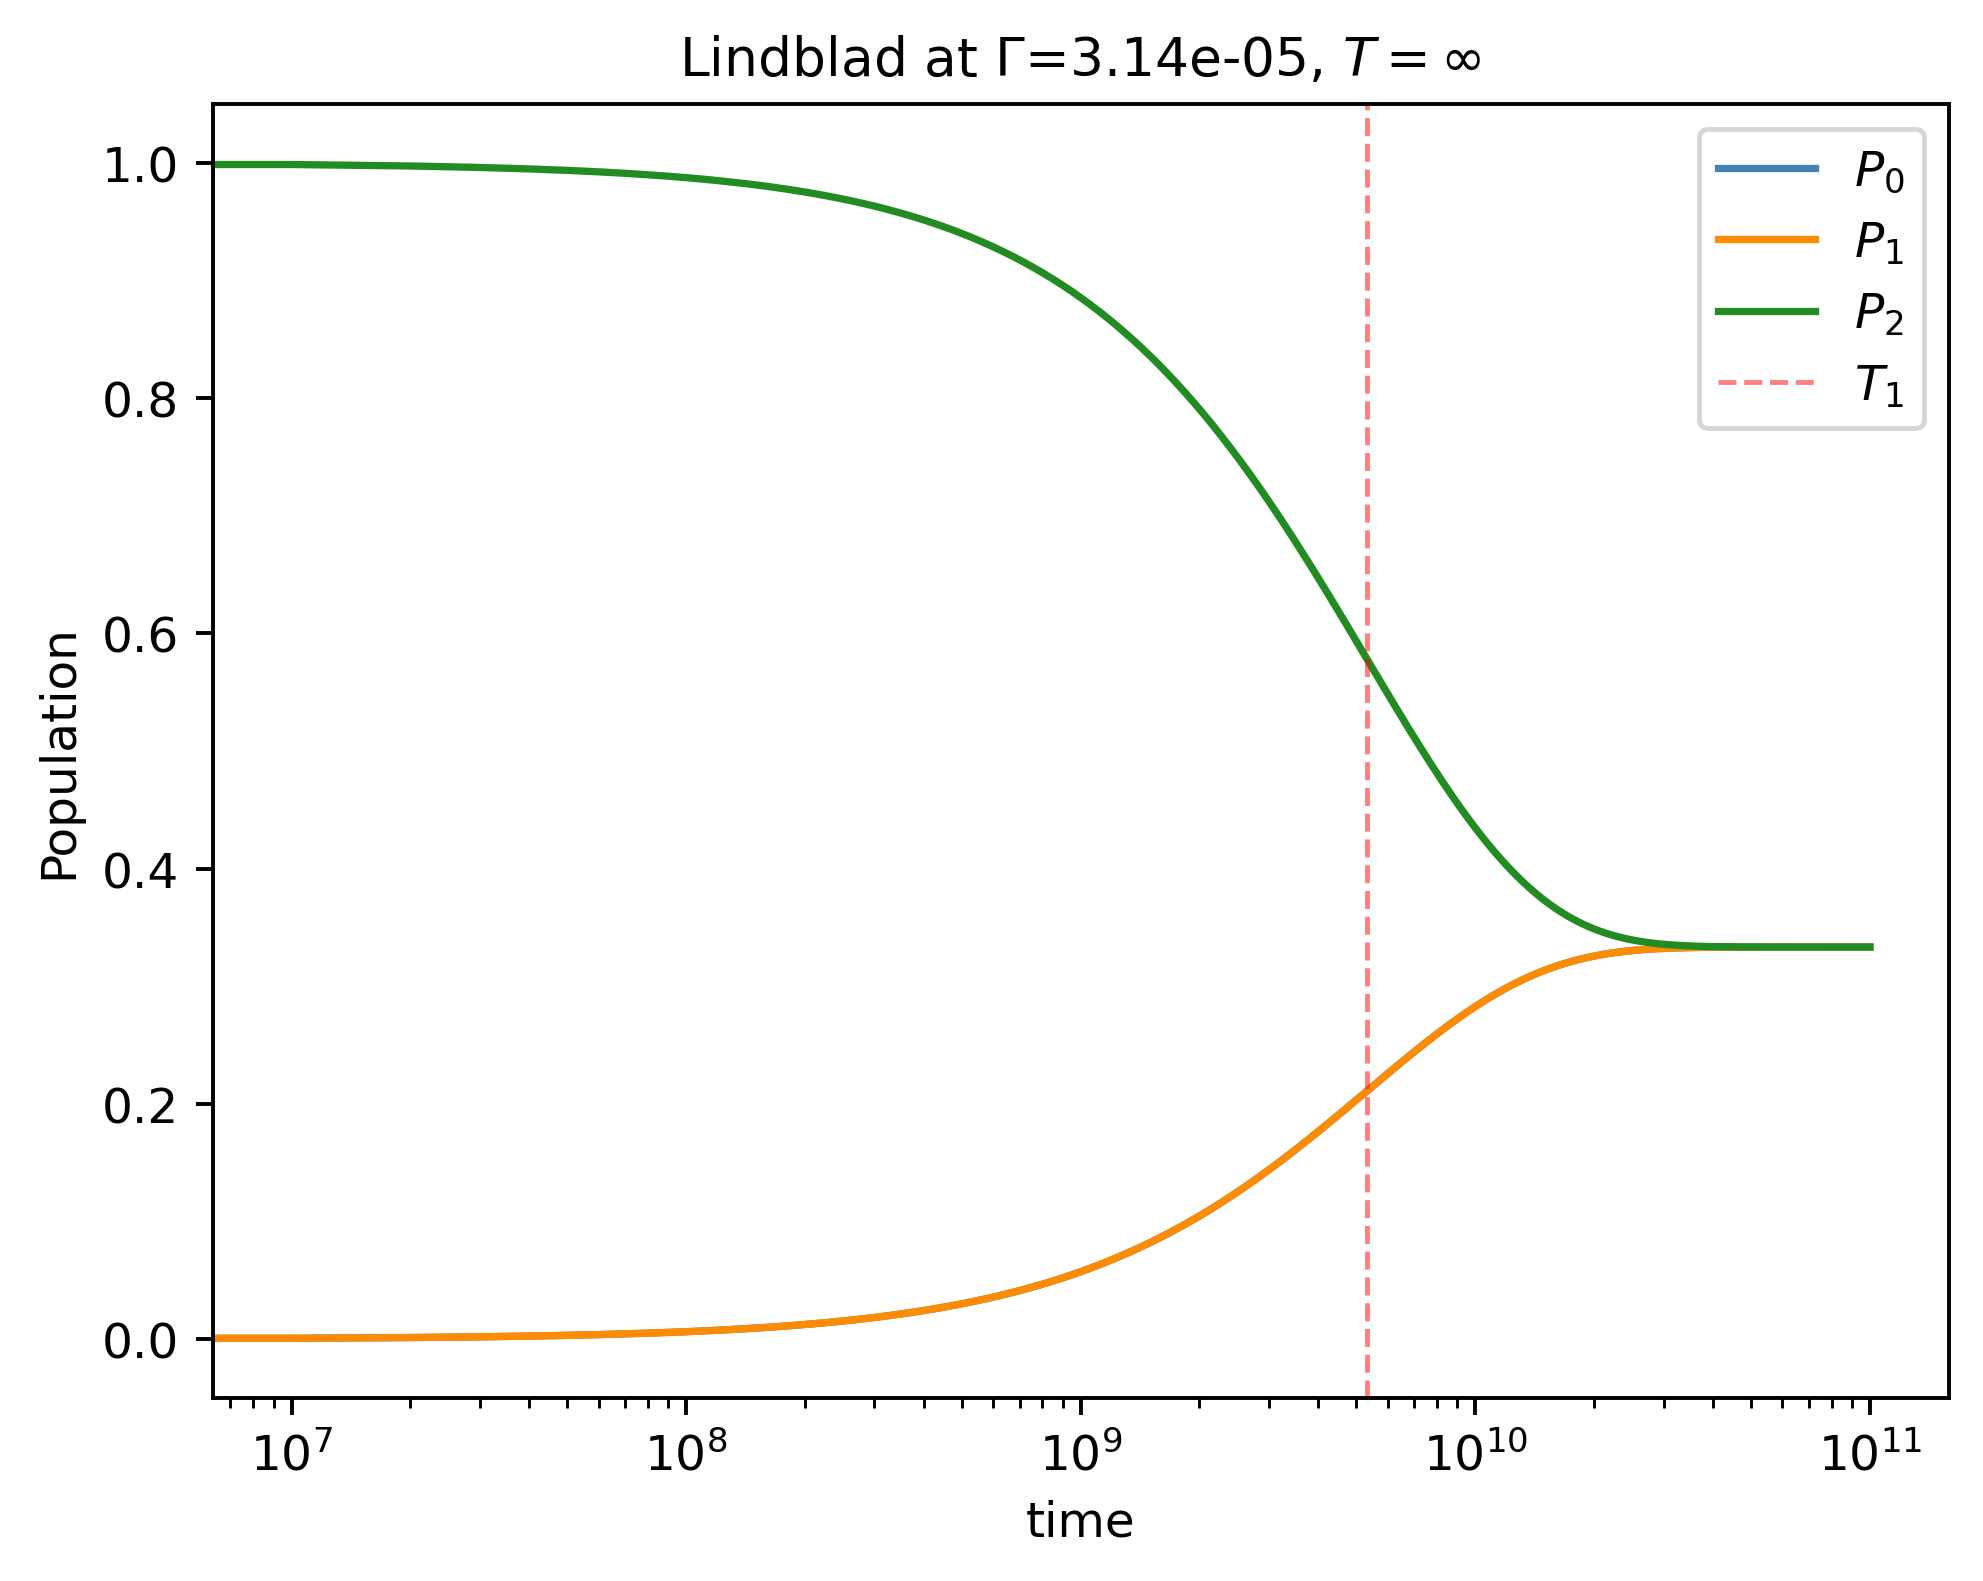

[-3.14000000e-05+4.91278126e-20j -3.13999686e-05+9.99998000e-02j
 -3.13999686e-05-9.99998000e-02j -3.13999058e-05-1.00000400e-01j
 -3.13999058e-05+1.00000400e-01j -1.57000314e-05-2.00000199e-01j
 -1.57000314e-05+2.00000199e-01j -1.88398475e-10-8.01560746e-20j
 -1.08490692e-18-3.45176873e-20j]


In [12]:
import numpy as np
from utils import evolve_density_matrix
import matplotlib.pyplot as plt
from sympy import *
from sympy import symbols 
from scipy.linalg import expm
from sympy.physics.quantum import TensorProduct
plt.rcParams['figure.dpi']=350
#choose hilbert space dimension
N=3

#Define system Hamiltonian
J, epsilon, Gamma , delta= symbols('J epsilon Gamma delta', real=True)
couplings = {
    (0, 1): J,
    (1, 0): J,
    
    (0, 2): epsilon + delta,
    (2, 0): epsilon + delta,
    
    (1, 2): epsilon - delta,
    (2, 1): epsilon - delta,
    
    #(0, 3): epsilon,
    #(3, 0): epsilon,
    
    #(2, 3): epsilon,
    #(3, 2): epsilon,
    
    #(1, 3): epsilon,
    #(3, 1): epsilon
    
}
H = Matrix(N, N, lambda i, j: 0 if i == j else couplings.get((i, j)))

def build_Liouvillian(Hamiltonian):
    Id=eye(N)
    #Define Jump operators 
    jump_ops=[]
    for k in range(N):
        L_k=Matrix(N,N, lambda i,j: 1 if i==j==k else 0)
        jump_ops.append(L_k)
    #Define dissipator
    D=zeros(N**2,N**2)
    for m in jump_ops:
        D+=TensorProduct(m,m.H)-Rational(1,2)*TensorProduct(m*m.H,Id)-(Rational(1,2))*TensorProduct(Id,(m*m).H)
    #Construct Liouvillian
    L=-I*TensorProduct(Hamiltonian,Id)+TensorProduct(Id,I*Hamiltonian.H)+Gamma*D
    return L

L=build_Liouvillian(H)

#Define initial density matrix in state |0><0|
rho_0=np.array([[0,0,0],[0,0,0],[0,0,1]],dtype=np.complex128)
rho_0_vectorized=rho_0.reshape(-1) #vectorize DM and convert into a numpy array for simulation

#array of times for time evolution
times=np.linspace(0,1e11,10000)
params= {J: 0.1, epsilon: 1e-4, Gamma: 3.14e-5, delta: 0}
L_num=np.array(L.subs(params), dtype=np.complex128) #Make numeric Liouvillian

#Exponentiation of the Liouvillian to obtain time evolution DM
rho_t=evolve_density_matrix(L_num, times, rho_0, U=None, n_jobs=-1, energy_basis=False)
rho_t=np.array(rho_t)

c=['steelblue','darkorange','forestgreen','orange']
sites=['A','B','C']
for k in range(N):
    plt.plot(times, rho_t[:,k,k].real, label=rf'$P_{k}$', color=c[k])
#plt.plot(times,(1/N)*np.ones_like(times),ls='--',color='grey',lw='1')
plt.axvline(x=5.305*(10**9), color='red', linestyle='--',alpha=0.5,lw=1,label="$T_1$")
plt.xlabel('time')
plt.ylabel('Population')
plt.title(f'Lindblad at $\\Gamma$={params[Gamma]}, $T=\\infty$', fontsize=11)
plt.xscale('log')
plt.legend()
plt.show() 

eigvals=np.sort_complex(np.linalg.eigvals(L_num))
print(eigvals)    